# Baseline Decision Tree (Frozen)

Notebook trình bày lớp baseline Decision Tree của Hoàng: hợp đồng thí nghiệm chia sẻ, kiểm toán tiền xử lý không rò rỉ, cấu hình bị đóng băng, đánh giá, confusion matrix, cấu trúc cây, feature importance, quy tắc quyết định và diễn giải.

> Phạm vi: notebook này không tinh chỉnh `max_depth`, `min_samples_split`, `min_samples_leaf`, `ccp_alpha`, `class_weight` hay cross-validation. Nó import module dữ liệu và tiền xử lý chung của `src` thay vì sao chép pipeline.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display
from sklearn.metrics import RocCurveDisplay

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'src').is_dir() and (candidate / 'data' / 'bank-full.csv').is_file():
            return candidate
    raise FileNotFoundError('Không tìm thấy thư mục gốc của dự án.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RESULTS_DIR = PROJECT_ROOT / 'outputs' / 'results'
FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures'
TREES_DIR = PROJECT_ROOT / 'outputs' / 'trees'
SHARED_DIR = PROJECT_ROOT / 'outputs' / 'shared'

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 30)
print('Đã nhận diện thư mục gốc của dự án.')

Đã nhận diện thư mục gốc của dự án.


## 1. Thiết kế thí nghiệm

Giữ nguyên official stratified split 80/20 và frozen baseline: `DecisionTreeClassifier` với `random_state=42`, không tìm kiếm siêu tham số, không pruning, không class weighting, không cross-validation tuning. Test set chỉ dùng một lần để đánh giá. Toàn bộ artifact được sinh bởi `src.baseline_workflow.run_baseline_workflow` và tái sử dụng lại nếu đã tồn tại.

In [2]:
from src.baseline_workflow import run_baseline_workflow

required_artifacts = [
    RESULTS_DIR / 'baseline_metrics.json',
    RESULTS_DIR / 'classification_report.csv',
    RESULTS_DIR / 'feature_importance.csv',
    RESULTS_DIR / 'preprocessing_audit.json',
    RESULTS_DIR / 'run_manifest.json',
    TREES_DIR / 'tree_analysis.json',
    TREES_DIR / 'early_splits.json',
    TREES_DIR / 'baseline_tree_model.joblib',
    FIGURES_DIR / 'confusion_matrix.png',
    FIGURES_DIR / 'baseline_tree_top_levels.png',
    FIGURES_DIR / 'baseline_tree_full_structure.png',
    FIGURES_DIR / 'top_feature_importance.png',
]
missing = [path for path in required_artifacts if not path.is_file()]
if missing:
    print('Thiếu artifacts, bắt đầu chạy lại workflow baseline...')
    summary = run_baseline_workflow()
    display(summary)
else:
    print('Đã tải các kết quả baseline có sẵn.')

metrics = json.loads((RESULTS_DIR / 'baseline_metrics.json').read_text(encoding='utf-8'))
statistics = json.loads((TREES_DIR / 'tree_analysis.json').read_text(encoding='utf-8'))
importance = pd.read_csv(RESULTS_DIR / 'feature_importance.csv')
audit = json.loads((RESULTS_DIR / 'preprocessing_audit.json').read_text(encoding='utf-8'))
manifest = json.loads((RESULTS_DIR / 'run_manifest.json').read_text(encoding='utf-8'))
split_manifest = json.loads((SHARED_DIR / 'split_manifest.json').read_text(encoding='utf-8'))
classification_report = pd.read_csv(RESULTS_DIR / 'classification_report.csv')
print(f"Training rows: {split_manifest['train_rows']:,} | Test rows: {split_manifest['test_rows']:,}")

Đã tải các kết quả baseline có sẵn.
Training rows: 36,168 | Test rows: 9,043


## 2. Hợp đồng thí nghiệm chia sẻ (Shared Experiment Contract)

Việc load dữ liệu nằm trong module Python dùng chung. Notebook gọi entry point chính thức để mọi model experiment nhận cùng một stratified split.

In [3]:
contract = pd.DataFrame(
    {
        'Value': [
            split_manifest['dataset_path'],
            split_manifest['target_column'],
            f"{split_manifest['positive_class_name']} ({split_manifest['positive_class']})",
            f"{1 - split_manifest['test_size']:.0%} / {split_manifest['test_size']:.0%}, stratified",
            split_manifest['random_state'],
            split_manifest['train_rows'],
            split_manifest['test_rows'],
            len(split_manifest['transformed_feature_names']),
        ]
    },
    index=[
        'Dataset', 'Target', 'Positive class', 'Train/test split',
        'random_state', 'Training rows', 'Test rows', 'Transformed features',
    ],
)
display(contract)

,Value
Dataset,data/bank-full.csv
Target,y
Positive class,yes (1)
Train/test split,"80% / 20%, stratified"
random_state,42
Training rows,36168
Test rows,9043
Transformed features,51


## 3. Tiền xử lý không rò rỉ (Leakage-Safe Preprocessing)

One-hot encoder chỉ được **fit trên tập train**. Tập test chỉ transform, và target `y` được tách trước khi tiền xử lý.

In [4]:
leakage_audit = pd.Series(audit, name='Result')
display(leakage_audit.to_frame())

,Result
feature_name_count,51
feature_names_aligned,True
preprocessor_fit_partition,training only
shared_pipeline,src.data + src.preprocessing
split_before_preprocessor_fit,True
split_row_count,45211
target_column,y
target_excluded_from_raw_partitions,True
target_excluded_from_transformed_features,True
test_partition_usage,transform and evaluation only


## 4. Baseline bị đóng băng (Frozen Baseline)

Mọi constructor parameter đều explicit và bị đóng băng. Các experiment sau phải tạo estimator riêng thay vì đổi model tham chiếu này.

In [5]:
configuration = pd.DataFrame(
    list(manifest['configuration'].items()),
    columns=['Parameter', 'Value'],
)
display(configuration)

,Parameter,Value
0,ccp_alpha,0.0
1,class_weight,None
2,criterion,gini
3,max_depth,None
4,max_features,None
5,max_leaf_nodes,None
6,min_impurity_decrease,0.0
7,min_samples_leaf,1
8,min_samples_split,2
9,min_weight_fraction_leaf,0.0


## 5. Đánh giá Baseline

Toàn bộ giá trị dưới được tính trên tập test giữ nguyên. Precision, recall, F1-score thuộc positive class `yes`. ROC-AUC dùng `predict_proba`.

In [6]:
metric_frame = pd.DataFrame(
    {
        'Metric': [
            'Accuracy', 'Error Rate', 'Precision (yes)', 'Recall (yes)',
            'F1-score (yes)', 'ROC-AUC', 'Training Accuracy', 'Test Accuracy',
            'Train-Test Accuracy Gap',
        ],
        'Result': [
            metrics['accuracy'], metrics['error_rate'], metrics['precision'],
            metrics['recall'], metrics['f1_score'], metrics['roc_auc'],
            metrics['train_accuracy'], metrics['test_accuracy'],
            metrics['train_test_accuracy_gap'],
        ],
    }
)
display(metric_frame)

,Metric,Result
0,Accuracy,0.873714
1,Error Rate,0.126286
2,Precision (yes),0.461111
3,Recall (yes),0.470699
4,F1-score (yes),0.465856
5,ROC-AUC,0.698906
6,Training Accuracy,1.000000
7,Test Accuracy,0.873714
8,Train-Test Accuracy Gap,0.126286


## 6. Confusion Matrix

Confusion matrix và đường ROC được xuất trực tiếp từ workflow. Trục ngang là nhãn dự đoán, trục dọc là nhãn thực.

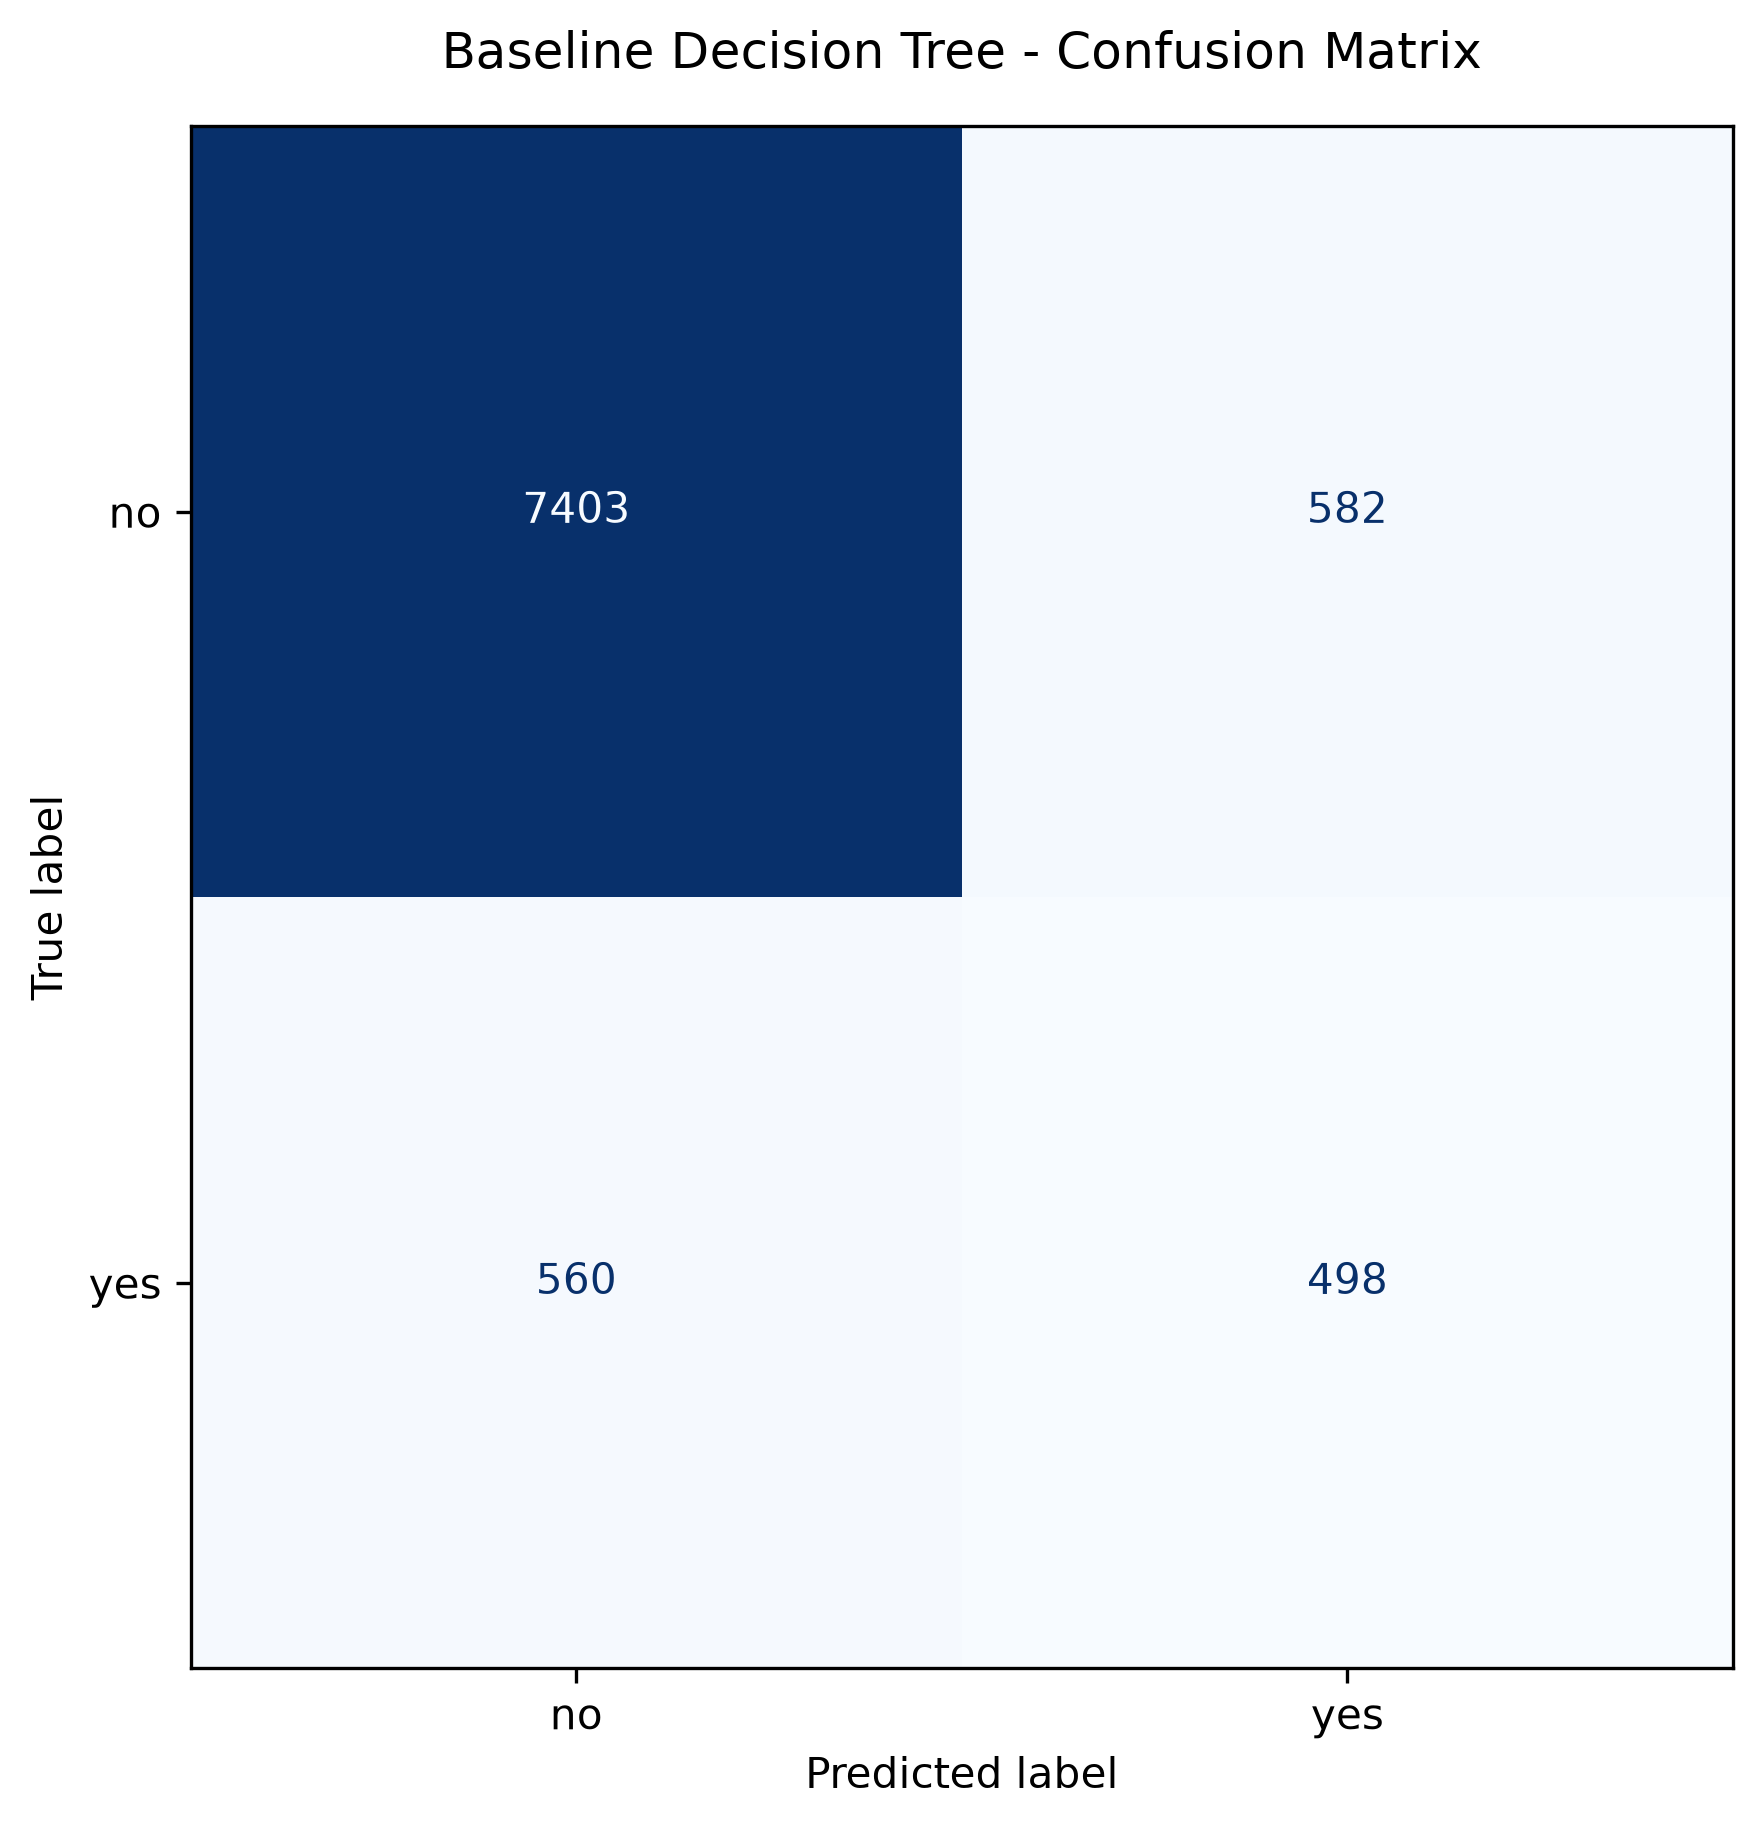

Confusion matrix [tn, fp; fn, tp]:
[[7403  582]
 [ 560  498]]


In [7]:
display(Image(filename=str(FIGURES_DIR / 'confusion_matrix.png')))
matrix = np.array(metrics['confusion_matrix'])
print('Confusion matrix [tn, fp; fn, tp]:')
print(matrix)

## 7. Cấu trúc cây và bằng chứng quá khớp

Cây baseline không giới hạn đạt training accuracy rất cao nhưng thấp hơn rõ rệt trên test. Độ sâu và số lá lớn cho thấy cây đã ghi nhớ nhiều chi tiết tập train.

,Metric,Result
0,Depth,34.000000
1,Nodes,5751.000000
2,Leaves,2876.000000
3,Training Accuracy,1.000000
4,Test Accuracy,0.873714
5,Train-Test Gap,0.126286


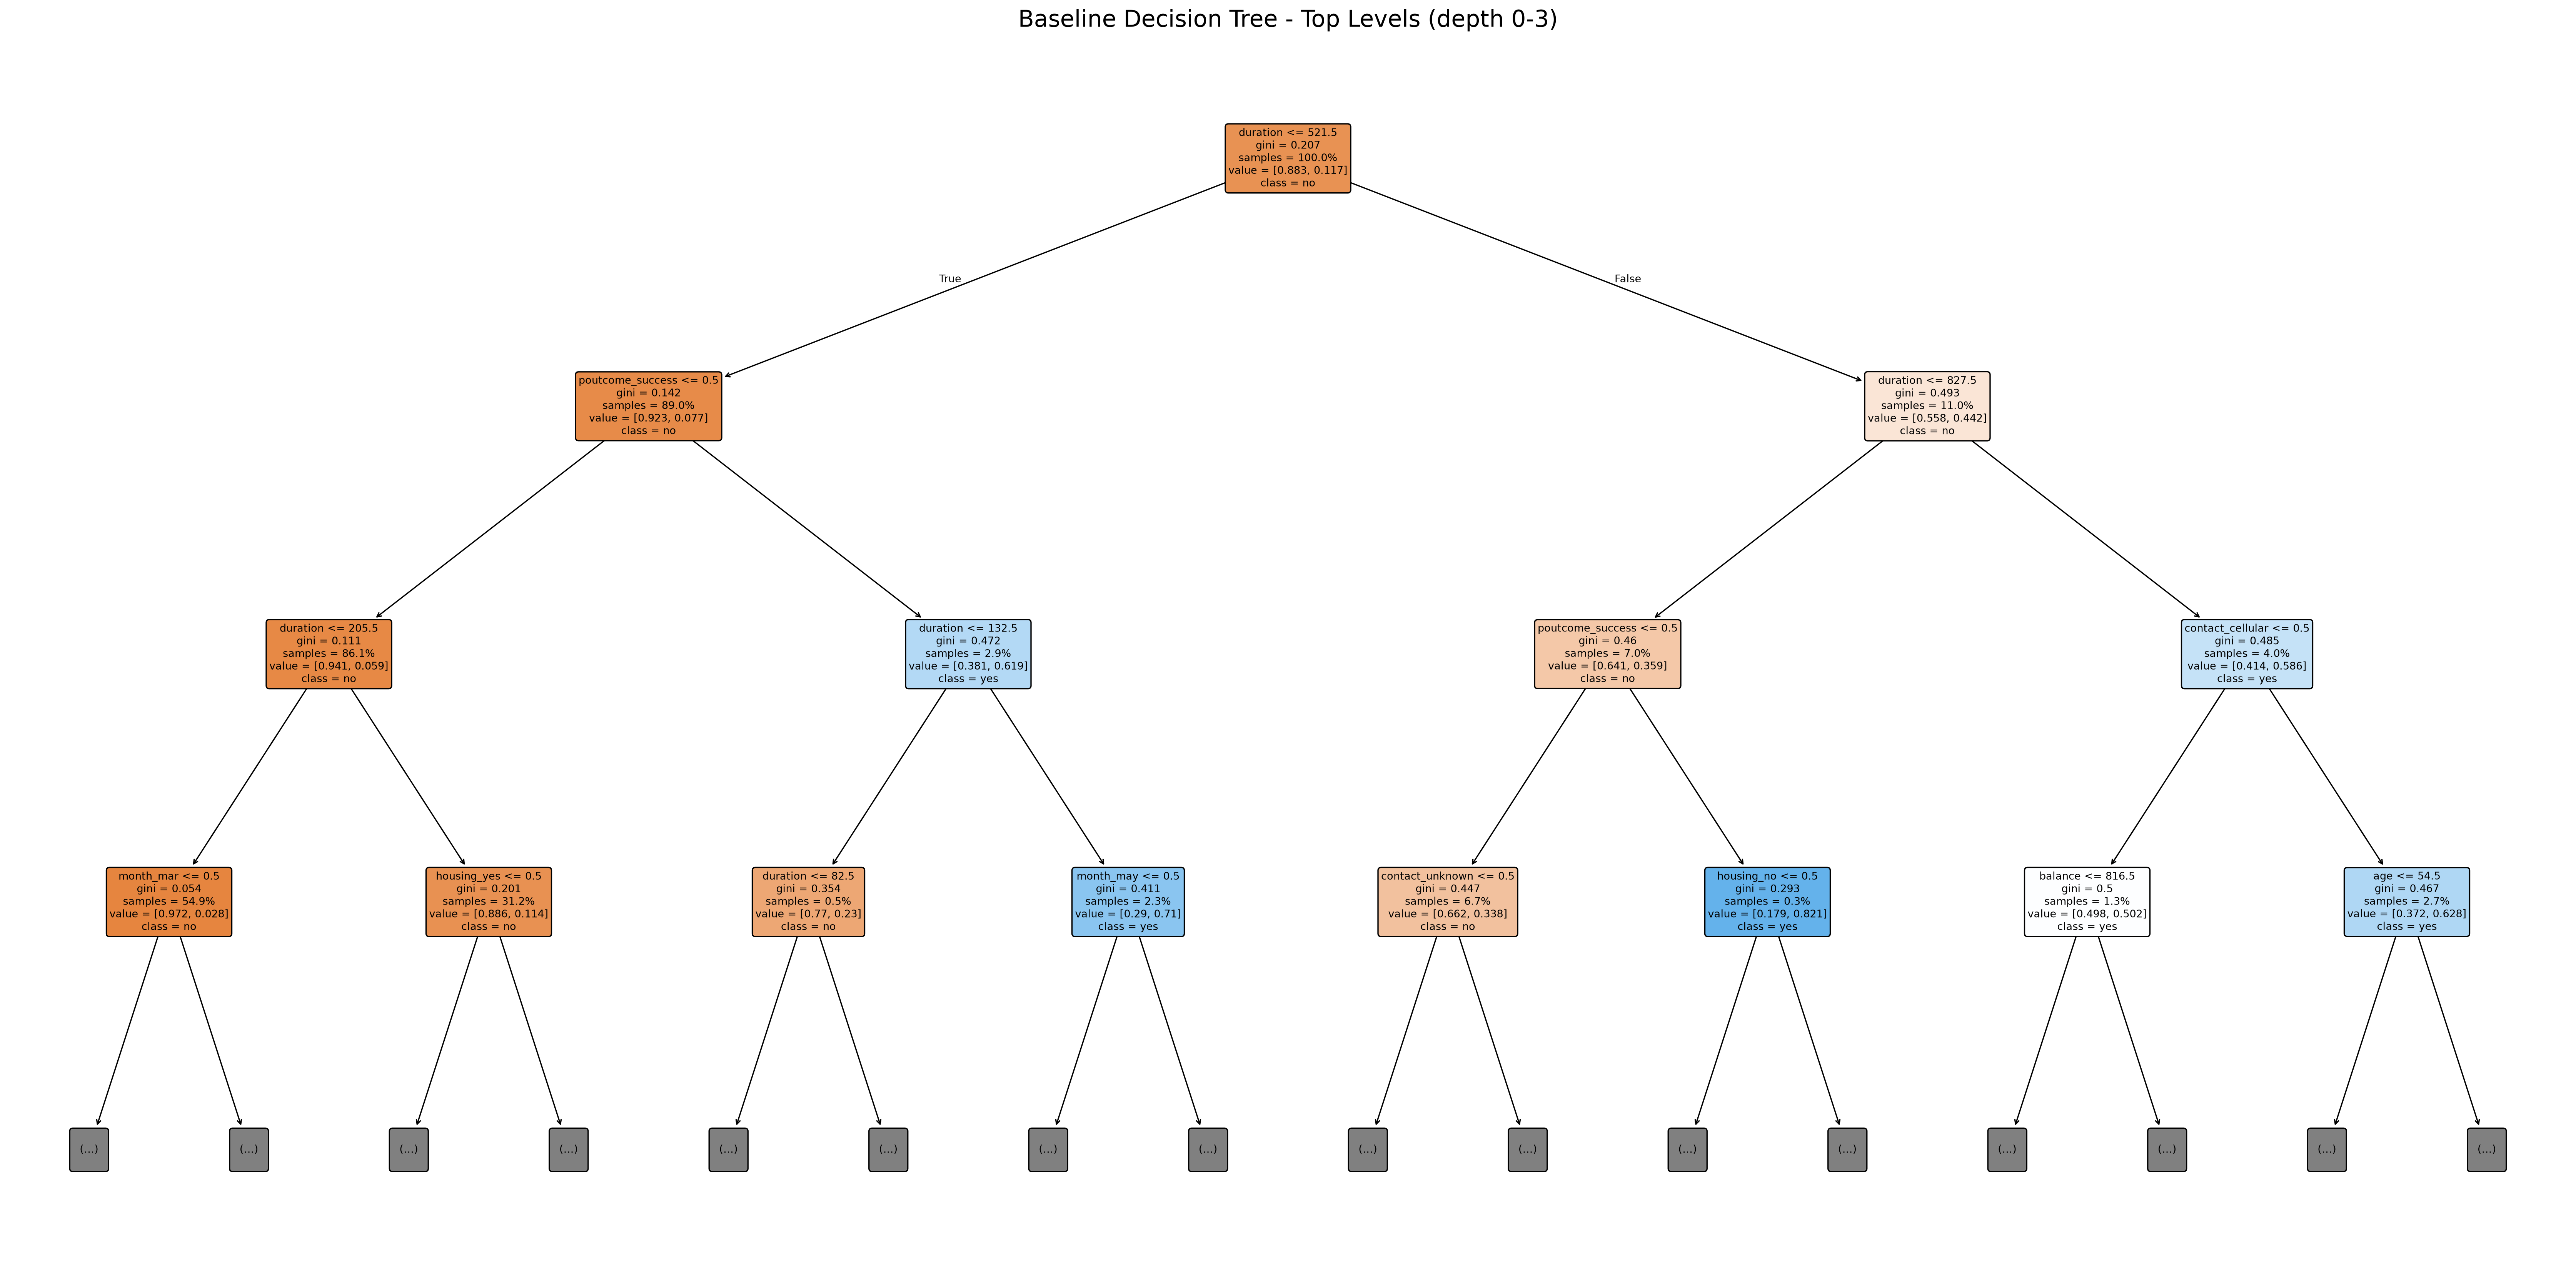

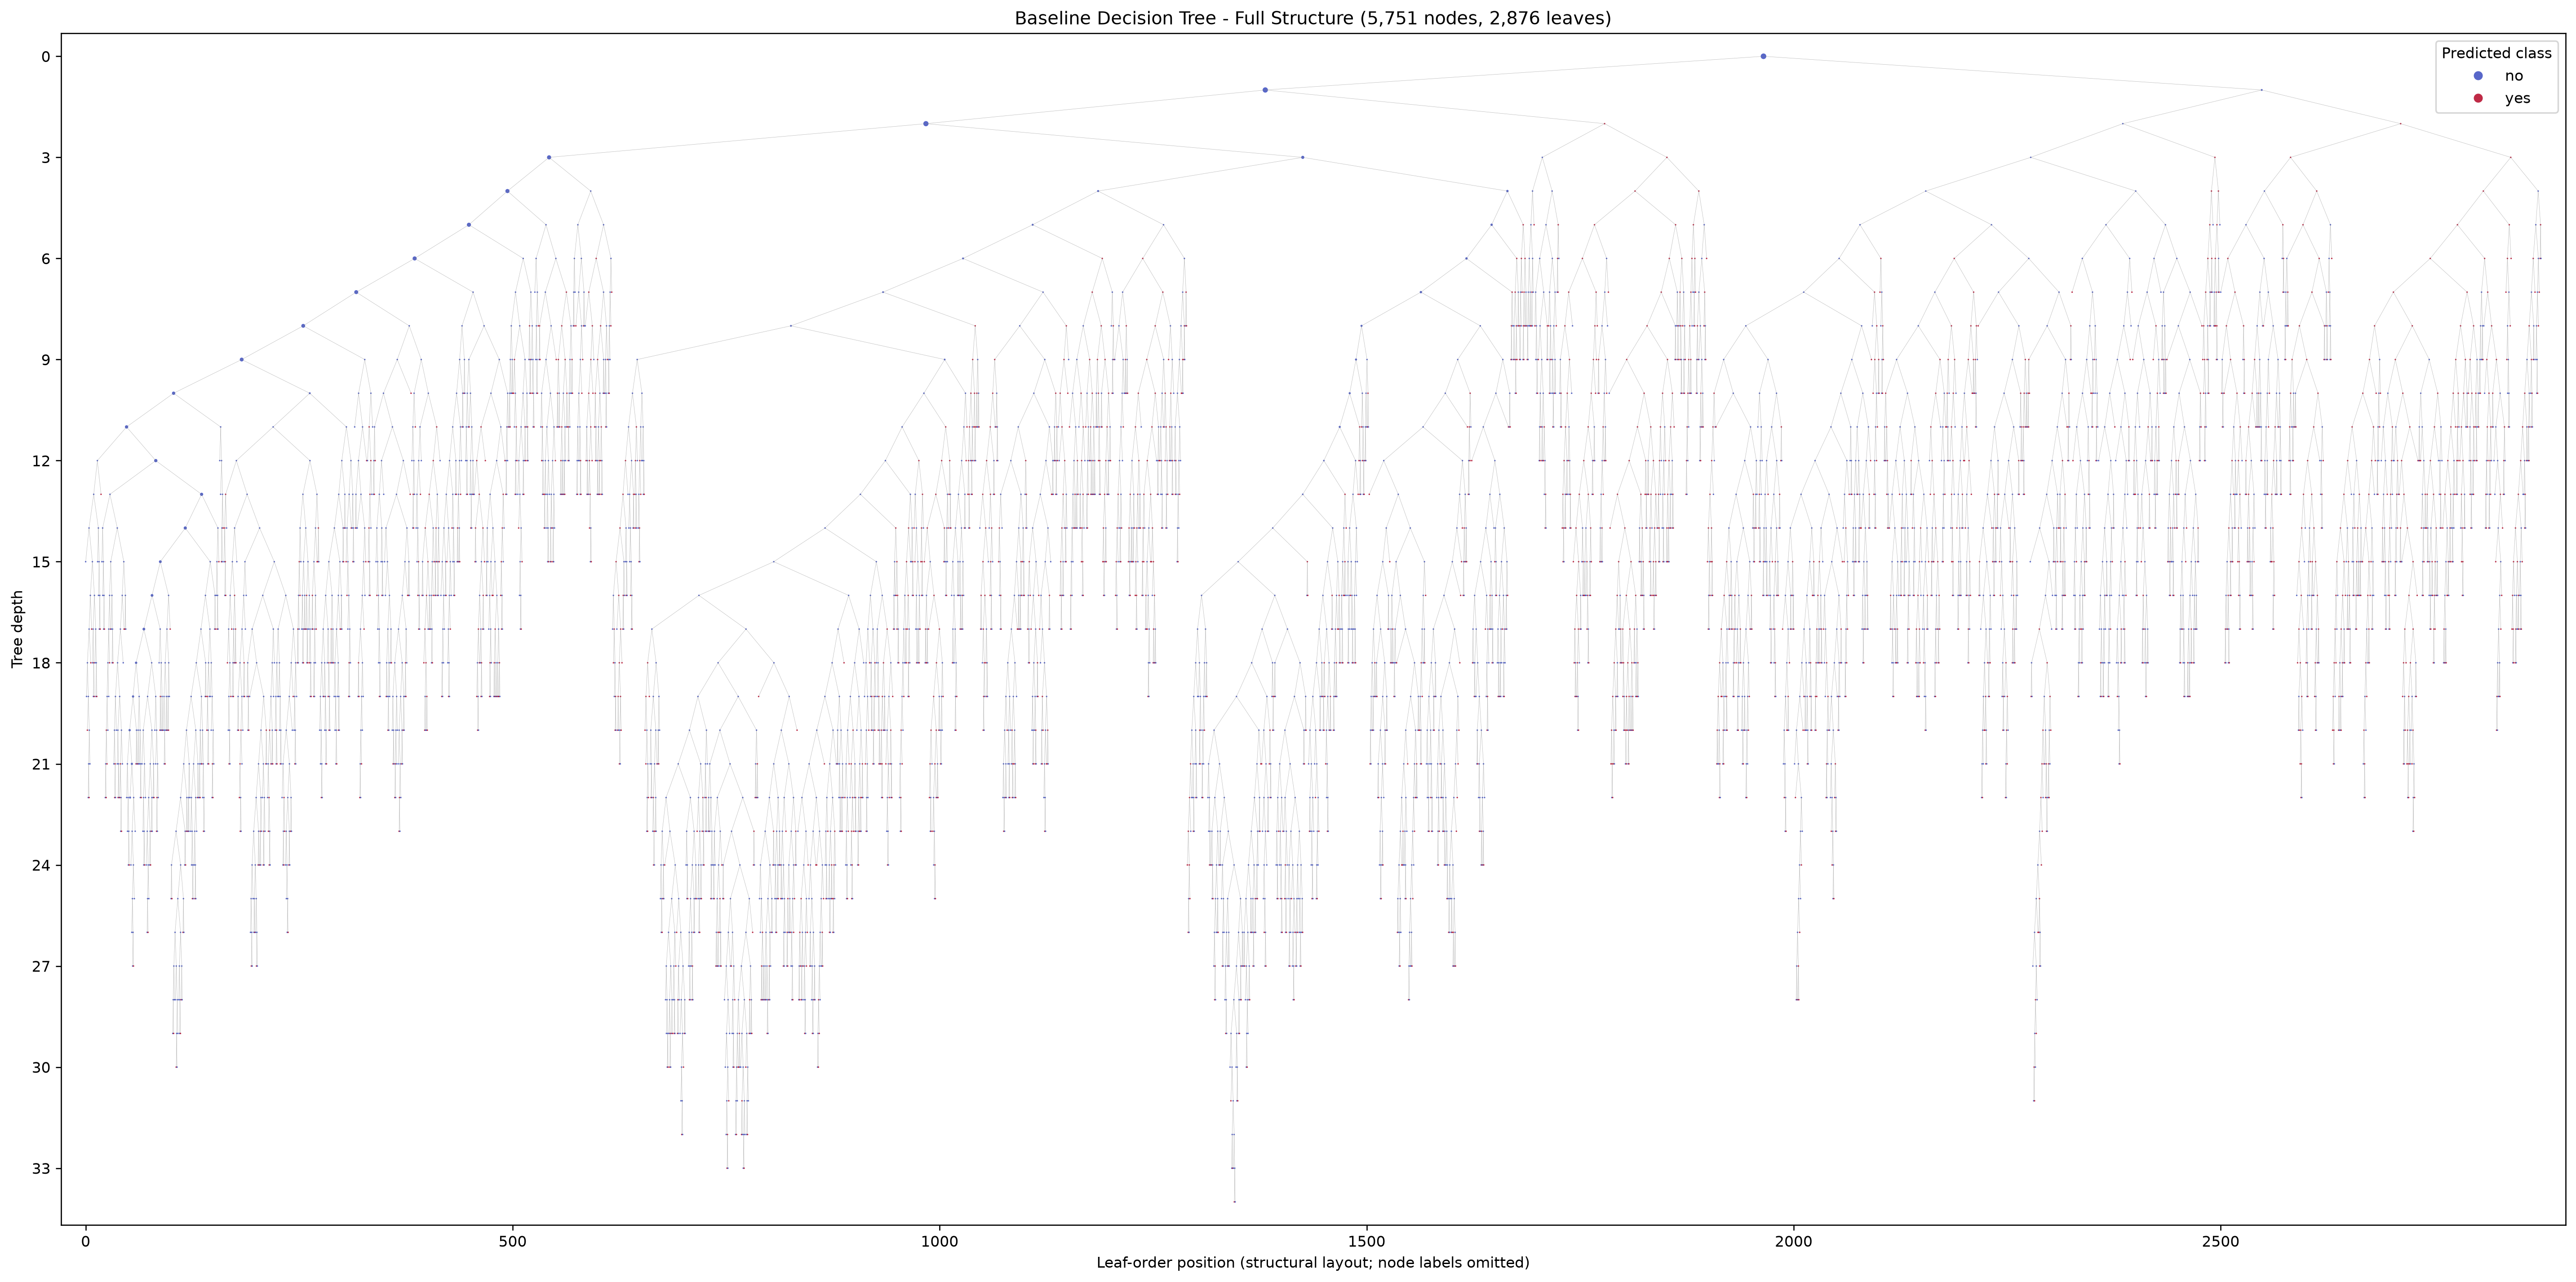

In [8]:
tree_frame = pd.DataFrame(
    {
        'Metric': ['Depth', 'Nodes', 'Leaves', 'Training Accuracy', 'Test Accuracy', 'Train-Test Gap'],
        'Result': [
            statistics['depth'], statistics['nodes'], statistics['leaves'],
            statistics['train_accuracy'], statistics['test_accuracy'],
            statistics['train_test_accuracy_gap'],
        ],
    }
)
display(tree_frame)
display(Image(filename=str(FIGURES_DIR / 'baseline_tree_top_levels.png')))
display(Image(filename=str(FIGURES_DIR / 'baseline_tree_full_structure.png')))

## 8. Feature Importance và các split quan trọng

Giá trị `feature_importances_` của cây được ánh xạ một-một sang tên feature đã transform. Các split qua depth 2 mô tả nhánh gốc và nhánh trong.

Rank,Feature,Importance
1,duration,0.276517
2,balance,0.103049
3,poutcome_success,0.091619
4,age,0.087798
5,day,0.084751
6,pdays,0.045028
7,campaign,0.030971
8,housing_yes,0.017515
9,month_mar,0.014057
10,month_jun,0.013801


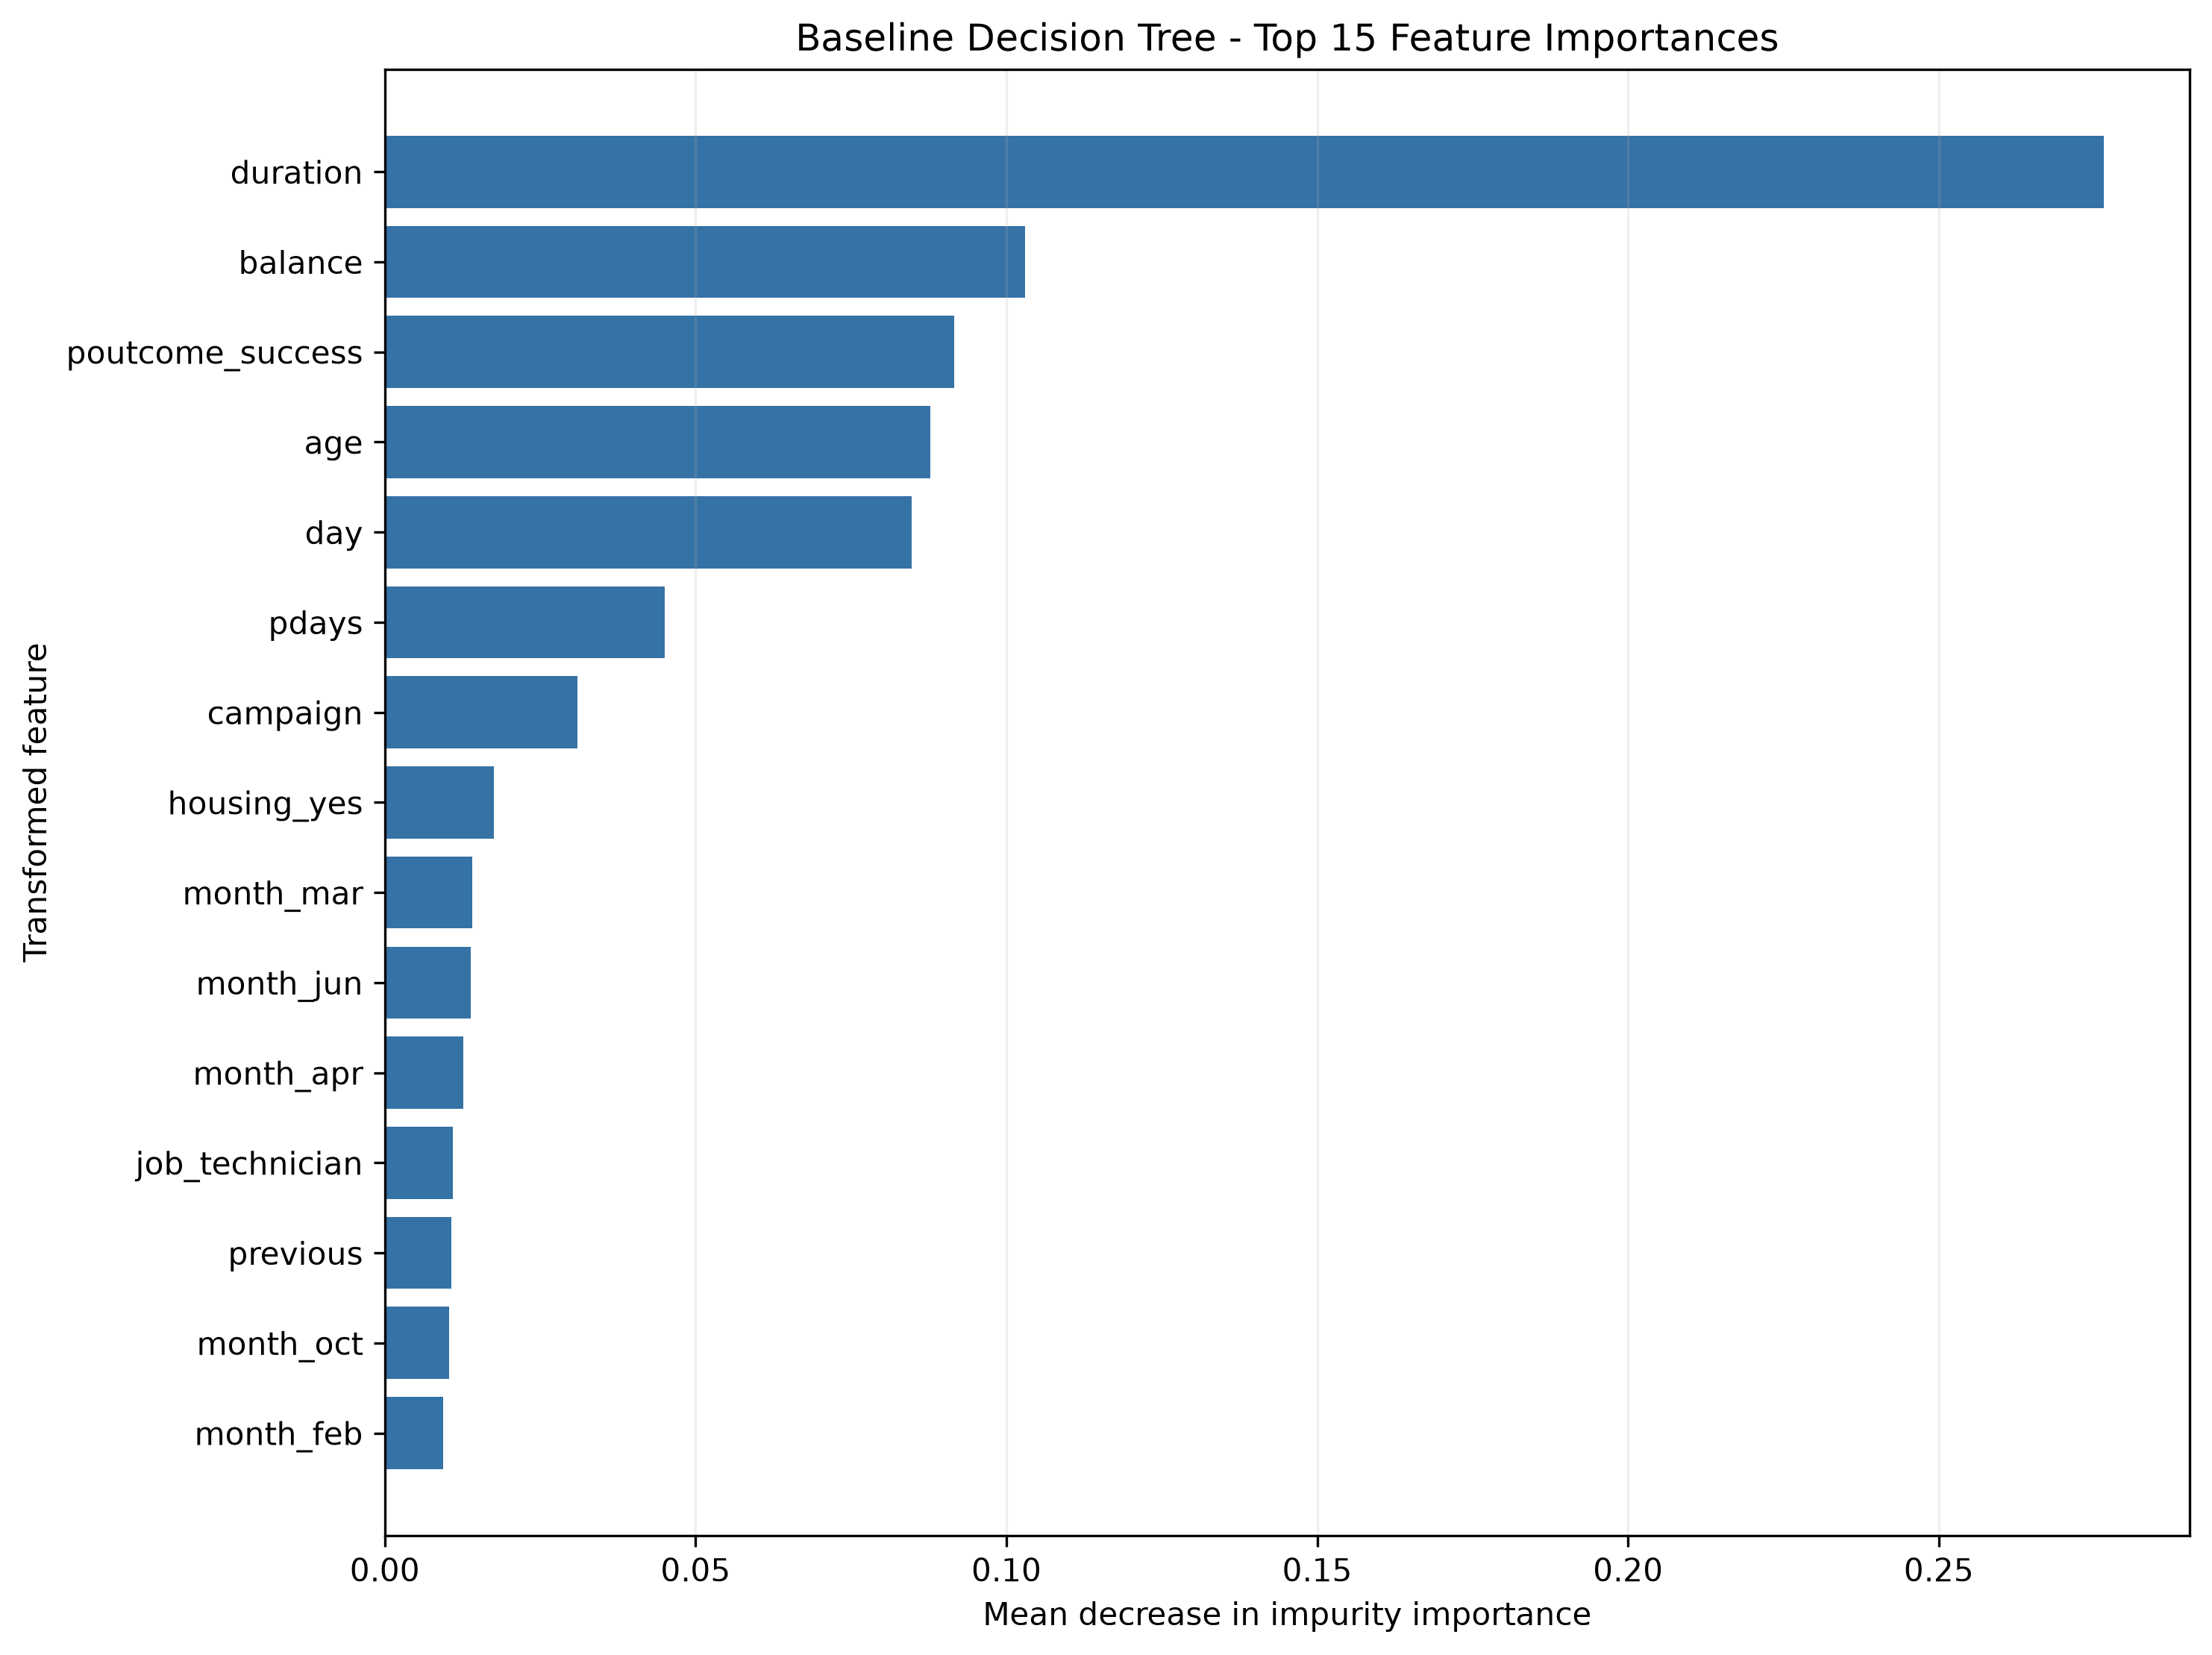

Depth,Branch path,Split feature,Threshold,Training rows,Node prediction
0,root,duration,521.500000,36168,no
1,rootL,poutcome_success,0.500000,32180,no
2,rootLL,duration,205.500000,31145,no
2,rootLR,duration,132.500000,1035,yes
1,rootR,duration,827.500000,3988,no
2,rootRL,poutcome_success,0.500000,2540,no
2,rootRR,contact_cellular,0.500000,1448,yes


In [9]:
display(importance.head(10).style.hide(axis='index'))
display(Image(filename=str(FIGURES_DIR / 'top_feature_importance.png')))

early_splits = json.loads((TREES_DIR / 'early_splits.json').read_text(encoding='utf-8'))['splits']
splits_frame = pd.DataFrame(
    [
        {
            'Depth': s['depth'],
            'Branch path': s['branch_path'],
            'Split feature': s['feature'],
            'Threshold': s['threshold'],
            'Training rows': s['training_samples'],
            'Node prediction': s['predicted_class'],
        }
        for s in early_splits
    ]
)
display(splits_frame.style.hide(axis='index'))

## 9. Quy tắc quyết định đại diện

Các rule lá được chọn chương trình theo support cao và độ dài đường dẫn trung bình. Chúng mô tả association học được, không phải hệ quả nhân quả.

In [10]:
rules_text = (TREES_DIR / 'representative_rules.md').read_text(encoding='utf-8')
display(Markdown(rules_text))

# Representative Baseline Decision Rules

These are selected high-support leaf paths from the fitted baseline. They are descriptive model rules, not causal statements.

## Rule 1: predict `no`

- duration <= 521.500
- poutcome is not 'success'
- duration <= 205.500
- month is not 'mar'
- month is 'oct'
- duration <= 95.500
- marital is not 'divorced'

Leaf support: 76 training rows; leaf purity: 1.000; path depth: 7.
Held-out support: 23 rows; held-out purity: 1.000.

## Rule 2: predict `no`

- duration <= 521.500
- poutcome is 'success'
- duration <= 132.500
- duration > 82.500
- month is not 'sep'
- pdays > 102.500
- balance > 247.500
- month is not 'mar'
- age <= 61.000
- month is not 'oct'

Leaf support: 46 training rows; leaf purity: 1.000; path depth: 10.
Held-out support: 7 rows; held-out purity: 0.714.

## Rule 3: predict `yes`

- duration > 521.500
- duration <= 827.500
- poutcome is 'success'
- housing is 'no'
- day <= 30.500
- job is not 'entrepreneur'
- day > 1.500
- education is not 'unknown'

Leaf support: 55 training rows; leaf purity: 1.000; path depth: 8.
Held-out support: 21 rows; held-out purity: 0.810.

## Rule 4: predict `yes`

- duration > 521.500
- duration > 827.500
- contact is 'cellular'
- age <= 54.500
- poutcome is 'success'
- day > 8.000

Leaf support: 24 training rows; leaf purity: 1.000; path depth: 6.
Held-out support: 5 rows; held-out purity: 0.600.


## 10. Kết luận / Diễn giải

Tóm tắt nhanh điểm mạnh, điểm yếu và ngữ cảnh đánh giá của baseline frozen.

In [11]:
majority_class = int(np.argmax([sum(row) for row in metrics['confusion_matrix']]))
class_support = [sum(row) for row in metrics['confusion_matrix']]
majority_accuracy = class_support[majority_class] / sum(class_support)
gap = metrics['accuracy'] - majority_accuracy
overfit = (
    'Có bằng chứng quá khớp rõ rệt'
    if metrics['train_test_accuracy_gap'] >= 0.05 and metrics['train_accuracy'] >= 0.99
    else 'Không có khoảng cách train-test lớn'
)
conclusion = f"""**Tóm tắt baseline frozen**

- Accuracy test: **{metrics['accuracy']:.4f}**, cao hơn luật luôn chọn lớp đa số **{gap:+.4f}** (đạt {majority_accuracy:.4f}).
- Positive-class recall (yes): **{metrics['recall']:.4f}**, F1 (yes): **{metrics['f1_score']:.4f}**.
- {overfit}: train accuracy {metrics['train_accuracy']:.4f} so với test {metrics['test_accuracy']:.4f} (gap {metrics['train_test_accuracy_gap']:.4f}).
- Cây: depth {statistics['depth']}, {statistics['leaves']:,} lá, {statistics['nodes']:,} node.
- Điểm mạnh: phi tuyến, dễ kiểm tra qua nhánh/lá. Điểm yếu: khó diễn giải toàn bộ, recall lớp thiểu số yếu, importance không nhân quả; `duration` chỉ có sau cuộc gọi (lo ngại deployment leakage, không phải train/test bug).
"""
display(Markdown(conclusion))

**Tóm tắt baseline frozen**

- Accuracy test: **0.8737**, cao hơn luật luôn chọn lớp đa số **-0.0093** (đạt 0.8830).
- Positive-class recall (yes): **0.4707**, F1 (yes): **0.4659**.
- Có bằng chứng quá khớp rõ rệt: train accuracy 1.0000 so với test 0.8737 (gap 0.1263).
- Cây: depth 34, 2,876 lá, 5,751 node.
- Điểm mạnh: phi tuyến, dễ kiểm tra qua nhánh/lá. Điểm yếu: khó diễn giải toàn bộ, recall lớp thiểu số yếu, importance không nhân quả; `duration` chỉ có sau cuộc gọi (lo ngại deployment leakage, không phải train/test bug).
